# Facial Expression Recognition Challenge

## Setup

In [2]:
!pip install wandb -q

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import zipfile
import os

zip_path = '/content/drive/MyDrive/facial expression recognition/challenges-in-representation-learning-facial-expression-recognition-challenge.zip'
extract_path = '/content/fer_data'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print(os.listdir(extract_path))

['fer2013.tar.gz', 'test.csv', 'example_submission.csv', 'train.csv', 'icml_face_data.csv']


In [5]:
import wandb
wandb.login()

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results


wandb: Enter your choice: 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.


wandb: Paste your API key and hit enter: ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: lbati23 (lbati23-free-university-of-tbilisi-) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [6]:
!git config --global user.email "lbati23@freeuni.edu.ge"
!git config --global user.name "LukaBatilashvili07"

## Data Loading

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.model_selection import train_test_split
import torch.nn as nn
import torch.optim as optim

emotion_labels = {
    0: 'Angry', 1: 'Disgust', 2: 'Fear',
    3: 'Happy', 4: 'Sad', 5: 'Surprise', 6: 'Neutral'
}

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Device: cuda


In [9]:
train_df = pd.read_csv('/content/fer_data/train.csv')
test_df = pd.read_csv('/content/fer_data/test.csv')

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("\nClass distribution:")
print(train_df['emotion'].value_counts().sort_index())

Train shape: (28709, 2)
Test shape: (7178, 1)

Class distribution:
emotion
0    3995
1     436
2    4097
3    7215
4    4830
5    3171
6    4965
Name: count, dtype: int64


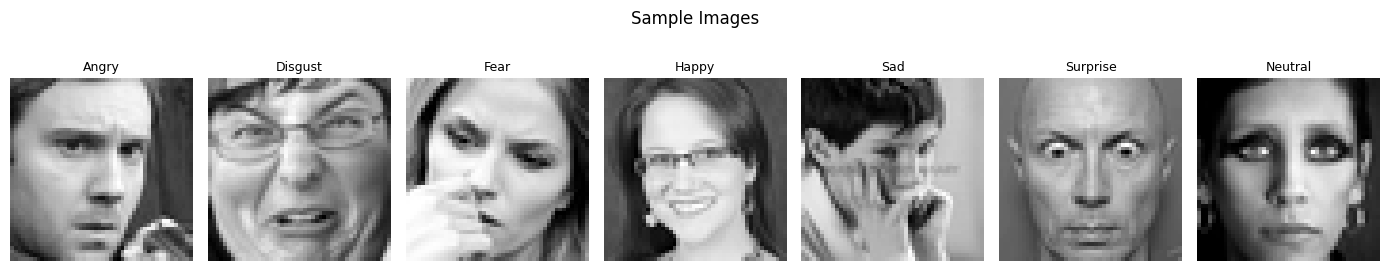

In [10]:
def pixels_to_image(pixel_string):
    pixels = np.array(pixel_string.split(), dtype=np.uint8)
    return pixels.reshape(48, 48)

fig, axes = plt.subplots(1, 7, figsize=(14, 3))
for emotion_id, ax in enumerate(axes):
    sample = train_df[train_df['emotion'] == emotion_id].iloc[0]
    img = pixels_to_image(sample['pixels'])
    ax.imshow(img, cmap='gray')
    ax.set_title(emotion_labels[emotion_id], fontsize=9)
    ax.axis('off')
plt.suptitle('Sample Images')
plt.tight_layout()
plt.show()

In [11]:
class FERDataset(Dataset):
    def __init__(self, df, transform=None):
        self.pixels = df['pixels'].values
        self.labels = df['emotion'].values if 'emotion' in df.columns else None
        self.transform = transform

    def __len__(self):
        return len(self.pixels)

    def __getitem__(self, idx):
        img = np.array(self.pixels[idx].split(), dtype=np.float32)
        img = img.reshape(48, 48) / 255.0
        img = torch.tensor(img).unsqueeze(0)
        if self.transform:
            img = self.transform(img)
        if self.labels is not None:
            return img, torch.tensor(self.labels[idx], dtype=torch.long)
        return img

In [12]:
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.RandomCrop(48, padding=4),
])

train_data, val_data = train_test_split(
    train_df, test_size=0.2, random_state=42, stratify=train_df['emotion']
)

train_dataset = FERDataset(train_data.reset_index(drop=True), transform=train_transform)
val_dataset = FERDataset(val_data.reset_index(drop=True))
test_dataset = FERDataset(test_df.reset_index(drop=True))

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=2)

print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

Train: 22967 | Val: 5742 | Test: 7178


## Model V1 Baseline CNN

In [ ]:
class ModelV1(nn.Module):
    def __init__(self):
        super(ModelV1, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 12 * 12, 256), nn.ReLU(),
            nn.Linear(256, 7)
        )

    def forward(self, x):
        return self.classifier(self.features(x))

model_v1 = ModelV1().to(device)
print(f"Total parameters: {sum(p.numel() for p in model_v1.parameters()):,}")

Total parameters: 2,380,167


Forward & Backward Check


In [ ]:
dummy_input = torch.randn(4, 1, 48, 48).to(device)
dummy_output = model_v1(dummy_input)
criterion = nn.CrossEntropyLoss()
dummy_labels = torch.randint(0, 7, (4,)).to(device)
loss = criterion(dummy_output, dummy_labels)
loss.backward()

print(f"Output shape: {dummy_output.shape}")
print(f"Random loss (≈1.946): {loss.item():.4f}")
print(f"Gradients exist: {all(p.grad is not None for p in model_v1.parameters())}")

Output shape: torch.Size([4, 7])
Random loss (≈1.946): 27.1860
Gradients exist: True


In [ ]:
model_v1 = ModelV1().to(device)
optimizer_test = optim.Adam(model_v1.parameters(), lr=1e-3)
batch_imgs, batch_labels = next(iter(train_loader))
batch_imgs, batch_labels = batch_imgs.to(device), batch_labels.to(device)

for i in range(50):
    optimizer_test.zero_grad()
    out = model_v1(batch_imgs)
    loss = criterion(out, batch_labels)
    loss.backward()
    optimizer_test.step()
    if (i+1) % 10 == 0:
        acc = (out.argmax(1) == batch_labels).float().mean()
        print(f"Step {i+1}: loss={loss.item():.4f}, acc={acc.item():.4f}")

Step 10: loss=1.2817, acc=0.5625
Step 20: loss=0.5128, acc=0.8594
Step 30: loss=0.1400, acc=0.9844
Step 40: loss=0.0279, acc=1.0000
Step 50: loss=0.0065, acc=1.0000


### V1 Experiment 1

In [ ]:
model_v1_exp1 = ModelV1().to(device)
optimizer = optim.Adam(model_v1_exp1.parameters(), lr=1e-3)

run = wandb.init(project="fer-challenge", name="v1_lr1e-3", config={
    'model': 'V1_Baseline', 'epochs': 30, 'lr': 1e-3, 'batch_size': 64
})

train_accs_v1_exp1, val_accs_v1_exp1 = [], []
best_val_acc_v1_exp1 = 0

for epoch in range(30):
    model_v1_exp1.train()
    train_loss, train_correct, train_total = 0, 0, 0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        out = model_v1_exp1(imgs)
        loss = criterion(out, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
        train_correct += (out.argmax(1) == labels).sum().item()
        train_total += labels.size(0)

    model_v1_exp1.eval()
    val_loss, val_correct, val_total = 0, 0, 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            out = model_v1_exp1(imgs)
            loss = criterion(out, labels)
            val_loss += loss.item()
            val_correct += (out.argmax(1) == labels).sum().item()
            val_total += labels.size(0)

    train_acc = train_correct / train_total
    val_acc = val_correct / val_total
    train_accs_v1_exp1.append(train_acc)
    val_accs_v1_exp1.append(val_acc)

    if val_acc > best_val_acc_v1_exp1:
        best_val_acc_v1_exp1 = val_acc

    print(f"Epoch {epoch+1}/30 | Train: {train_acc:.4f} | Val: {val_acc:.4f}")
    wandb.log({
        "train/loss": train_loss / len(train_loader),
        "train/accuracy": train_acc,
        "val/loss": val_loss / len(val_loader),
        "val/accuracy": val_acc,
        "epoch": epoch + 1
    })

wandb.finish()
print(f"\nV1 lr=1e-3 | Best Val Acc: {best_val_acc_v1_exp1:.4f}")

epoch,▁▁▂▂▂▃▃▃▄▄▅▅▅▆▆▆▇▇▇██
train/accuracy,▁▂▃▄▅▅▆▆▆▆▇▇▇▇▇▇█▇███
train/loss,█▇▆▆▅▄▄▃▃▃▃▂▂▂▂▂▂▁▁▁▁
val/accuracy,▁▂▃▄▅▅▆▆▆▇▇▇▇▇▇██████
val/loss,█▇▆▅▄▃▃▃▃▂▂▂▂▂▂▁▁▁▁▁▁
epoch,21
train/accuracy,0.51983
train/loss,1.25902
val/accuracy,0.53344
val/loss,1.21972


Epoch 1/30 | Train: 0.2805 | Val: 0.3551
Epoch 2/30 | Train: 0.3414 | Val: 0.4096
Epoch 3/30 | Train: 0.3751 | Val: 0.4361
Epoch 4/30 | Train: 0.4057 | Val: 0.4528
Epoch 5/30 | Train: 0.4250 | Val: 0.4761
Epoch 6/30 | Train: 0.4446 | Val: 0.4789
Epoch 7/30 | Train: 0.4557 | Val: 0.4915
Epoch 8/30 | Train: 0.4647 | Val: 0.5002
Epoch 9/30 | Train: 0.4752 | Val: 0.5061
Epoch 10/30 | Train: 0.4828 | Val: 0.5214
Epoch 11/30 | Train: 0.4869 | Val: 0.5098
Epoch 12/30 | Train: 0.4977 | Val: 0.5174
Epoch 13/30 | Train: 0.5021 | Val: 0.5301
Epoch 14/30 | Train: 0.5053 | Val: 0.5280
Epoch 15/30 | Train: 0.5123 | Val: 0.5463
Epoch 16/30 | Train: 0.5133 | Val: 0.5287
Epoch 17/30 | Train: 0.5183 | Val: 0.5266
Epoch 18/30 | Train: 0.5217 | Val: 0.5279
Epoch 19/30 | Train: 0.5313 | Val: 0.5418
Epoch 20/30 | Train: 0.5313 | Val: 0.5521
Epoch 21/30 | Train: 0.5291 | Val: 0.5439
Epoch 22/30 | Train: 0.5345 | Val: 0.5535
Epoch 23/30 | Train: 0.5387 | Val: 0.5498
Epoch 24/30 | Train: 0.5411 | Val: 0.5428
E

epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
train/accuracy,▁▃▃▄▅▅▅▆▆▆▆▇▇▇▇▇▇▇▇▇▇█████████
train/loss,█▇▆▅▅▄▄▄▃▃▃▃▃▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁
val/accuracy,▁▃▄▄▅▅▆▆▆▇▆▇▇▇█▇▇▇▇████▇██████
val/loss,█▇▆▅▄▃▃▃▃▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁
epoch,30
train/accuracy,0.55153
train/loss,1.17506
val/accuracy,0.55085
val/loss,1.16582



V1 lr=1e-3 | Best Val Acc: 0.5576


V1 Experiment 2

In [ ]:
model_v1_exp2 = ModelV1().to(device)
optimizer = optim.Adam(model_v1_exp2.parameters(), lr=1e-4)

run = wandb.init(project="fer-challenge", name="v1_lr1e-4", config={
    'model': 'V1_Baseline', 'epochs': 30, 'lr': 1e-4, 'batch_size': 64
})

train_accs_v1_exp2, val_accs_v1_exp2 = [], []
best_val_acc_v1_exp2 = 0

for epoch in range(30):
    # Train
    model_v1_exp2.train()
    train_loss, train_correct, train_total = 0, 0, 0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        out = model_v1_exp2(imgs)
        loss = criterion(out, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
        train_correct += (out.argmax(1) == labels).sum().item()
        train_total += labels.size(0)

    # Validate
    model_v1_exp2.eval()
    val_loss, val_correct, val_total = 0, 0, 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            out = model_v1_exp2(imgs)
            loss = criterion(out, labels)
            val_loss += loss.item()
            val_correct += (out.argmax(1) == labels).sum().item()
            val_total += labels.size(0)

    train_acc = train_correct / train_total
    val_acc = val_correct / val_total
    train_accs_v1_exp2.append(train_acc)
    val_accs_v1_exp2.append(val_acc)

    if val_acc > best_val_acc_v1_exp2:
        best_val_acc_v1_exp2 = val_acc

    print(f"Epoch {epoch+1}/30 | Train: {train_acc:.4f} | Val: {val_acc:.4f}")
    wandb.log({
        "train/loss": train_loss / len(train_loader),
        "train/accuracy": train_acc,
        "val/loss": val_loss / len(val_loader),
        "val/accuracy": val_acc,
        "epoch": epoch + 1
    })

wandb.finish()
print(f"\nV1 lr=1e-4 | Best Val Acc: {best_val_acc_v1_exp2:.4f}")

Epoch 1/30 | Train: 0.2638 | Val: 0.2832
Epoch 2/30 | Train: 0.3055 | Val: 0.3494
Epoch 3/30 | Train: 0.3278 | Val: 0.3521
Epoch 4/30 | Train: 0.3459 | Val: 0.3865
Epoch 5/30 | Train: 0.3539 | Val: 0.3821
Epoch 6/30 | Train: 0.3586 | Val: 0.3997
Epoch 7/30 | Train: 0.3658 | Val: 0.4143
Epoch 8/30 | Train: 0.3756 | Val: 0.4201
Epoch 9/30 | Train: 0.3882 | Val: 0.4319
Epoch 10/30 | Train: 0.3923 | Val: 0.4368
Epoch 11/30 | Train: 0.4028 | Val: 0.4392
Epoch 12/30 | Train: 0.4025 | Val: 0.4502
Epoch 13/30 | Train: 0.4133 | Val: 0.4563
Epoch 14/30 | Train: 0.4221 | Val: 0.4638
Epoch 15/30 | Train: 0.4246 | Val: 0.4633
Epoch 16/30 | Train: 0.4291 | Val: 0.4549
Epoch 17/30 | Train: 0.4341 | Val: 0.4673
Epoch 18/30 | Train: 0.4361 | Val: 0.4749
Epoch 19/30 | Train: 0.4398 | Val: 0.4688
Epoch 20/30 | Train: 0.4462 | Val: 0.4727
Epoch 21/30 | Train: 0.4498 | Val: 0.4704
Epoch 22/30 | Train: 0.4533 | Val: 0.4887
Epoch 23/30 | Train: 0.4511 | Val: 0.4828
Epoch 24/30 | Train: 0.4558 | Val: 0.4859
E

epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
train/accuracy,▁▂▃▄▄▄▄▅▅▅▆▆▆▆▆▇▇▇▇▇▇▇▇███████
train/loss,█▇▆▆▆▅▅▅▅▄▄▄▃▃▃▃▃▂▂▂▂▂▂▂▁▁▁▁▁▁
val/accuracy,▁▃▃▄▄▅▅▅▆▆▆▆▇▇▇▆▇▇▇▇▇█▇▇██████
val/loss,█▇▇▆▆▅▅▄▄▄▄▃▃▃▃▃▂▂▂▂▂▂▂▂▁▁▁▁▁▁
epoch,30
train/accuracy,0.47059
train/loss,1.39293
val/accuracy,0.50279
val/loss,1.31289



V1 lr=1e-4 | Best Val Acc: 0.5028


V1 underfitting : train da val accuracy orive dabalia. sachiroa meti layer da BatchNorm

### Model V2 CNN, BatchNorm, Dropout

In [20]:
class ModelV2(nn.Module):
    def __init__(self, dropout=0.5):
        super(ModelV2, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 3 * 3, 512), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(512, 256), nn.ReLU(), nn.Dropout(dropout * 0.6),
            nn.Linear(256, 7)
        )

    def forward(self, x):
        return self.classifier(self.features(x))

print(f"Total parameters: {sum(p.numel() for p in ModelV2().parameters()):,}")

Total parameters: 1,702,087


V2 Experiment 1

In [ ]:
criterion = nn.CrossEntropyLoss()

model_v2_exp1 = ModelV2(dropout=0.5).to(device)
optimizer = optim.Adam(model_v2_exp1.parameters(), lr=1e-3)

run = wandb.init(project="fer-challenge", name="v2_lr1e-3_dropout0.5", config={
    'model': 'V2_Deeper', 'epochs': 30, 'lr': 1e-3,
    'batch_size': 64, 'dropout': 0.5, 'batch_norm': True
})

train_accs_v2_exp1, val_accs_v2_exp1 = [], []
best_val_acc_v2_exp1 = 0

for epoch in range(30):
    model_v2_exp1.train()
    train_loss, train_correct, train_total = 0, 0, 0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        out = model_v2_exp1(imgs)
        loss = criterion(out, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
        train_correct += (out.argmax(1) == labels).sum().item()
        train_total += labels.size(0)

    model_v2_exp1.eval()
    val_loss, val_correct, val_total = 0, 0, 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            out = model_v2_exp1(imgs)
            loss = criterion(out, labels)
            val_loss += loss.item()
            val_correct += (out.argmax(1) == labels).sum().item()
            val_total += labels.size(0)

    train_acc = train_correct / train_total
    val_acc = val_correct / val_total
    train_accs_v2_exp1.append(train_acc)
    val_accs_v2_exp1.append(val_acc)

    if val_acc > best_val_acc_v2_exp1:
        best_val_acc_v2_exp1 = val_acc
        torch.save(model_v2_exp1.state_dict(), 'v2_exp1_best.pth')

    print(f"Epoch {epoch+1}/30 | Train: {train_acc:.4f} | Val: {val_acc:.4f}")
    wandb.log({
        "train/loss": train_loss / len(train_loader),
        "train/accuracy": train_acc,
        "val/loss": val_loss / len(val_loader),
        "val/accuracy": val_acc,
        "epoch": epoch + 1
    })

wandb.finish()
print(f"\nV2 exp1 | Best Val Acc: {best_val_acc_v2_exp1:.4f}")

Epoch 1/30 | Train: 0.2755 | Val: 0.4016
Epoch 2/30 | Train: 0.4069 | Val: 0.4390
Epoch 3/30 | Train: 0.4435 | Val: 0.4680
Epoch 4/30 | Train: 0.4765 | Val: 0.5115
Epoch 5/30 | Train: 0.4866 | Val: 0.5209
Epoch 6/30 | Train: 0.4995 | Val: 0.5138
Epoch 7/30 | Train: 0.5186 | Val: 0.5421
Epoch 8/30 | Train: 0.5232 | Val: 0.5394
Epoch 9/30 | Train: 0.5368 | Val: 0.5573
Epoch 10/30 | Train: 0.5392 | Val: 0.5611
Epoch 11/30 | Train: 0.5471 | Val: 0.5613
Epoch 12/30 | Train: 0.5529 | Val: 0.5801
Epoch 13/30 | Train: 0.5550 | Val: 0.5838
Epoch 14/30 | Train: 0.5637 | Val: 0.5763
Epoch 15/30 | Train: 0.5697 | Val: 0.5808
Epoch 16/30 | Train: 0.5731 | Val: 0.5946
Epoch 17/30 | Train: 0.5778 | Val: 0.5911
Epoch 18/30 | Train: 0.5818 | Val: 0.5914
Epoch 19/30 | Train: 0.5851 | Val: 0.5827
Epoch 20/30 | Train: 0.5909 | Val: 0.5930
Epoch 21/30 | Train: 0.5889 | Val: 0.6092
Epoch 22/30 | Train: 0.5959 | Val: 0.5989
Epoch 23/30 | Train: 0.6031 | Val: 0.6036
Epoch 24/30 | Train: 0.6058 | Val: 0.6028
E

epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
train/accuracy,▁▄▄▅▅▅▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇████████
train/loss,█▆▅▄▄▄▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁
val/accuracy,▁▂▃▅▅▅▆▅▆▆▆▇▇▇▇▇▇▇▇▇█▇█▇█▇█▇▇█
val/loss,█▆▆▅▄▅▄▄▃▃▃▃▃▃▃▂▂▂▃▂▁▂▂▂▁▂▁▃▁▁
epoch,30
train/accuracy,0.62455
train/loss,1.01484
val/accuracy,0.61912
val/loss,1.05053



V2 exp1 | Best Val Acc: 0.6191


V2 Experiment 2

In [ ]:
model_v2_exp2 = ModelV2(dropout=0.5).to(device)
optimizer = optim.Adam(model_v2_exp2.parameters(), lr=1e-4)

run = wandb.init(project="fer-challenge", name="v2_lr1e-4_dropout0.5", config={
    'model': 'V2_Deeper', 'epochs': 30, 'lr': 1e-4,
    'batch_size': 64, 'dropout': 0.5, 'batch_norm': True
})

train_accs_v2_exp2, val_accs_v2_exp2 = [], []
best_val_acc_v2_exp2 = 0

for epoch in range(30):
    model_v2_exp2.train()
    train_loss, train_correct, train_total = 0, 0, 0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        out = model_v2_exp2(imgs)
        loss = criterion(out, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
        train_correct += (out.argmax(1) == labels).sum().item()
        train_total += labels.size(0)

    model_v2_exp2.eval()
    val_loss, val_correct, val_total = 0, 0, 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            out = model_v2_exp2(imgs)
            loss = criterion(out, labels)
            val_loss += loss.item()
            val_correct += (out.argmax(1) == labels).sum().item()
            val_total += labels.size(0)

    train_acc = train_correct / train_total
    val_acc = val_correct / val_total
    train_accs_v2_exp2.append(train_acc)
    val_accs_v2_exp2.append(val_acc)

    if val_acc > best_val_acc_v2_exp2:
        best_val_acc_v2_exp2 = val_acc
        torch.save(model_v2_exp2.state_dict(), 'v2_exp2_best.pth')

    print(f"Epoch {epoch+1}/30 | Train: {train_acc:.4f} | Val: {val_acc:.4f}")
    wandb.log({
        "train/loss": train_loss / len(train_loader),
        "train/accuracy": train_acc,
        "val/loss": val_loss / len(val_loader),
        "val/accuracy": val_acc,
        "epoch": epoch + 1
    })

wandb.finish()
print(f"\nV2 exp2 | Best Val Acc: {best_val_acc_v2_exp2:.4f}")

Epoch 1/30 | Train: 0.2718 | Val: 0.3622
Epoch 2/30 | Train: 0.3784 | Val: 0.4305
Epoch 3/30 | Train: 0.4189 | Val: 0.4664
Epoch 4/30 | Train: 0.4513 | Val: 0.4662
Epoch 5/30 | Train: 0.4709 | Val: 0.4986
Epoch 6/30 | Train: 0.4850 | Val: 0.4904
Epoch 7/30 | Train: 0.5020 | Val: 0.5310
Epoch 8/30 | Train: 0.5115 | Val: 0.5413
Epoch 9/30 | Train: 0.5186 | Val: 0.5333
Epoch 10/30 | Train: 0.5289 | Val: 0.5502
Epoch 11/30 | Train: 0.5319 | Val: 0.5606
Epoch 12/30 | Train: 0.5408 | Val: 0.5517
Epoch 13/30 | Train: 0.5470 | Val: 0.5749
Epoch 14/30 | Train: 0.5494 | Val: 0.5754
Epoch 15/30 | Train: 0.5539 | Val: 0.5761
Epoch 16/30 | Train: 0.5578 | Val: 0.5510
Epoch 17/30 | Train: 0.5643 | Val: 0.5763
Epoch 18/30 | Train: 0.5669 | Val: 0.5724
Epoch 19/30 | Train: 0.5685 | Val: 0.5765
Epoch 20/30 | Train: 0.5725 | Val: 0.5852
Epoch 21/30 | Train: 0.5732 | Val: 0.5900
Epoch 22/30 | Train: 0.5743 | Val: 0.5871
Epoch 23/30 | Train: 0.5800 | Val: 0.5801
Epoch 24/30 | Train: 0.5814 | Val: 0.6028
E

epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
train/accuracy,▁▃▄▅▅▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇██████████
train/loss,█▆▅▅▄▄▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁
val/accuracy,▁▃▄▄▅▅▆▆▆▆▇▆▇▇▇▆▇▇▇▇▇▇▇█▇▇████
val/loss,█▆▅▅▄▄▃▃▃▃▂▃▂▂▂▃▂▂▂▂▂▂▂▁▁▂▁▁▁▁
epoch,30
train/accuracy,0.59503
train/loss,1.07012
val/accuracy,0.60867
val/loss,1.04285



V2 exp2 | Best Val Acc: 0.6087


V2 Exoeriment 3

In [ ]:
model_v2_exp3 = ModelV2(dropout=0.3).to(device)
optimizer = optim.Adam(model_v2_exp3.parameters(), lr=1e-3)

run = wandb.init(project="fer-challenge", name="v2_lr1e-3_dropout0.3", config={
    'model': 'V2_Deeper', 'epochs': 30, 'lr': 1e-3,
    'batch_size': 64, 'dropout': 0.3, 'batch_norm': True
})

train_accs_v2_exp3, val_accs_v2_exp3 = [], []
best_val_acc_v2_exp3 = 0

for epoch in range(30):
    model_v2_exp3.train()
    train_loss, train_correct, train_total = 0, 0, 0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        out = model_v2_exp3(imgs)
        loss = criterion(out, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
        train_correct += (out.argmax(1) == labels).sum().item()
        train_total += labels.size(0)

    model_v2_exp3.eval()
    val_loss, val_correct, val_total = 0, 0, 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            out = model_v2_exp3(imgs)
            loss = criterion(out, labels)
            val_loss += loss.item()
            val_correct += (out.argmax(1) == labels).sum().item()
            val_total += labels.size(0)

    train_acc = train_correct / train_total
    val_acc = val_correct / val_total
    train_accs_v2_exp3.append(train_acc)
    val_accs_v2_exp3.append(val_acc)

    if val_acc > best_val_acc_v2_exp3:
        best_val_acc_v2_exp3 = val_acc
        torch.save(model_v2_exp3.state_dict(), 'v2_exp3_best.pth')

    print(f"Epoch {epoch+1}/30 | Train: {train_acc:.4f} | Val: {val_acc:.4f}")
    wandb.log({
        "train/loss": train_loss / len(train_loader),
        "train/accuracy": train_acc,
        "val/loss": val_loss / len(val_loader),
        "val/accuracy": val_acc,
        "epoch": epoch + 1
    })

wandb.finish()
print(f"\nV2 exp3 | Best Val Acc: {best_val_acc_v2_exp3:.4f}")

Epoch 1/30 | Train: 0.2859 | Val: 0.4014
Epoch 2/30 | Train: 0.4184 | Val: 0.4653
Epoch 3/30 | Train: 0.4630 | Val: 0.4817
Epoch 4/30 | Train: 0.4859 | Val: 0.5075
Epoch 5/30 | Train: 0.5046 | Val: 0.5298
Epoch 6/30 | Train: 0.5218 | Val: 0.5481
Epoch 7/30 | Train: 0.5290 | Val: 0.5406
Epoch 8/30 | Train: 0.5376 | Val: 0.5589
Epoch 9/30 | Train: 0.5454 | Val: 0.5719
Epoch 10/30 | Train: 0.5553 | Val: 0.5597
Epoch 11/30 | Train: 0.5591 | Val: 0.5502
Epoch 12/30 | Train: 0.5724 | Val: 0.5838
Epoch 13/30 | Train: 0.5753 | Val: 0.5944
Epoch 14/30 | Train: 0.5803 | Val: 0.5956
Epoch 15/30 | Train: 0.5872 | Val: 0.5571
Epoch 16/30 | Train: 0.5907 | Val: 0.6008
Epoch 17/30 | Train: 0.5961 | Val: 0.5853
Epoch 18/30 | Train: 0.6009 | Val: 0.5965
Epoch 19/30 | Train: 0.6038 | Val: 0.5998
Epoch 20/30 | Train: 0.6100 | Val: 0.6108
Epoch 21/30 | Train: 0.6133 | Val: 0.6090
Epoch 22/30 | Train: 0.6130 | Val: 0.5824
Epoch 23/30 | Train: 0.6178 | Val: 0.6188
Epoch 24/30 | Train: 0.6213 | Val: 0.6289
E

epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
train/accuracy,▁▄▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇████████
train/loss,█▆▅▄▄▄▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁
val/accuracy,▁▃▃▄▅▆▅▆▆▆▆▇▇▇▆▇▇▇▇▇▇▇██▇▇█▇██
val/loss,█▆▅▅▄▄▄▃▃▃▃▃▂▂▃▂▂▂▂▂▂▃▁▁▂▂▁▁▁▁
epoch,30
train/accuracy,0.63918
train/loss,0.95978
val/accuracy,0.62557
val/loss,1.01178



V2 exp3 | Best Val Acc: 0.6289


BatchNorm da Dropout kargi regulizer aris, am samidanac yvelaze kargi shedegi mesamem achvena val accuracy 62.5%

In [21]:
model_v2_exp4 = ModelV2(dropout=0.25).to(device)
optimizer = optim.Adam(model_v2_exp4.parameters(), lr=5e-4, weight_decay=1e-5)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=8, gamma=0.7)

run = wandb.init(project="fer-challenge", name="v2_exp4_lr5e-4_dropout0.25", config={
    'model': 'V2_Deeper', 'epochs': 30, 'lr': 5e-4,
    'batch_size': 64, 'dropout': 0.25, 'weight_decay': 1e-5,
    'optimizer': 'Adam', 'scheduler': 'StepLR'
})

train_accs_v2_exp4, val_accs_v2_exp4 = [], []
best_val_acc_v2_exp4 = 0

for epoch in range(30):
    model_v2_exp4.train()
    train_loss, train_correct, train_total = 0, 0, 0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        out = model_v2_exp4(imgs)
        loss = criterion(out, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
        train_correct += (out.argmax(1) == labels).sum().item()
        train_total += labels.size(0)

    model_v2_exp4.eval()
    val_loss, val_correct, val_total = 0, 0, 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            out = model_v2_exp4(imgs)
            loss = criterion(out, labels)
            val_loss += loss.item()
            val_correct += (out.argmax(1) == labels).sum().item()
            val_total += labels.size(0)

    train_acc = train_correct / train_total
    val_acc = val_correct / val_total
    train_accs_v2_exp4.append(train_acc)
    val_accs_v2_exp4.append(val_acc)

    if val_acc > best_val_acc_v2_exp4:
        best_val_acc_v2_exp4 = val_acc
        torch.save(model_v2_exp4.state_dict(), 'v2_exp4_best.pth')

    print(f"Epoch {epoch+1}/30 | Train: {train_acc:.4f} | Val: {val_acc:.4f}")
    wandb.log({
        "train/loss": train_loss / len(train_loader),
        "train/accuracy": train_acc,
        "val/loss": val_loss / len(val_loader),
        "val/accuracy": val_acc,
        "epoch": epoch + 1
    })
    scheduler.step()

wandb.finish()
print(f"\nV2 exp4 | Best Val Acc: {best_val_acc_v2_exp4:.4f}")

Epoch 1/30 | Train: 0.3461 | Val: 0.4617
Epoch 2/30 | Train: 0.4610 | Val: 0.4808
Epoch 3/30 | Train: 0.4915 | Val: 0.5214
Epoch 4/30 | Train: 0.5183 | Val: 0.5455
Epoch 5/30 | Train: 0.5280 | Val: 0.5333
Epoch 6/30 | Train: 0.5413 | Val: 0.5435
Epoch 7/30 | Train: 0.5504 | Val: 0.5629
Epoch 8/30 | Train: 0.5579 | Val: 0.5578
Epoch 9/30 | Train: 0.5722 | Val: 0.5796
Epoch 10/30 | Train: 0.5785 | Val: 0.5979
Epoch 11/30 | Train: 0.5842 | Val: 0.6024
Epoch 12/30 | Train: 0.5897 | Val: 0.5958
Epoch 13/30 | Train: 0.5962 | Val: 0.6015
Epoch 14/30 | Train: 0.5976 | Val: 0.6099
Epoch 15/30 | Train: 0.6010 | Val: 0.5975
Epoch 16/30 | Train: 0.6026 | Val: 0.6111
Epoch 17/30 | Train: 0.6198 | Val: 0.6021
Epoch 18/30 | Train: 0.6182 | Val: 0.6219
Epoch 19/30 | Train: 0.6253 | Val: 0.6200
Epoch 20/30 | Train: 0.6248 | Val: 0.6249
Epoch 21/30 | Train: 0.6300 | Val: 0.6315
Epoch 22/30 | Train: 0.6323 | Val: 0.6297
Epoch 23/30 | Train: 0.6359 | Val: 0.6358
Epoch 24/30 | Train: 0.6309 | Val: 0.6257
E

epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
train/accuracy,▁▄▄▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇█▇██████
train/loss,█▆▅▄▄▄▄▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁
val/accuracy,▁▂▃▄▄▄▅▅▆▆▇▆▆▇▆▇▇▇▇▇███▇██████
val/loss,█▆▅▄▅▄▄▄▃▃▂▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁
epoch,30
train/accuracy,0.65803
train/loss,0.90763
val/accuracy,0.6402
val/loss,0.96362



V2 exp4 | Best Val Acc: 0.6402


### Model V3 Transfer Learning

In [13]:
from torchvision import models

criterion = nn.CrossEntropyLoss()

In [14]:
class FERDataset3Ch(Dataset):
    def __init__(self, df, transform=None):
        self.pixels = df['pixels'].values
        self.labels = df['emotion'].values if 'emotion' in df.columns else None
        self.transform = transform

    def __len__(self):
        return len(self.pixels)

    def __getitem__(self, idx):
        img = np.array(self.pixels[idx].split(), dtype=np.float32)
        img = img.reshape(48, 48) / 255.0
        img = torch.tensor(img).unsqueeze(0).repeat(3, 1, 1)  # (3, 48, 48)
        if self.transform:
            img = self.transform(img)
        if self.labels is not None:
            return img, torch.tensor(self.labels[idx], dtype=torch.long)
        return img

train_transform_3ch = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.RandomCrop(48, padding=4),
])

train_dataset_3ch = FERDataset3Ch(train_data.reset_index(drop=True), transform=train_transform_3ch)
val_dataset_3ch = FERDataset3Ch(val_data.reset_index(drop=True))
test_dataset_3ch = FERDataset3Ch(test_df.reset_index(drop=True))

train_loader_3ch = DataLoader(train_dataset_3ch, batch_size=64, shuffle=True, num_workers=2)
val_loader_3ch = DataLoader(val_dataset_3ch, batch_size=64, shuffle=False, num_workers=2)
test_loader_3ch = DataLoader(test_dataset_3ch, batch_size=64, shuffle=False, num_workers=2)

print("3-channel DataLoaders ready")

3-channel DataLoaders ready


In [15]:
class ModelV3Fixed(nn.Module):
    def __init__(self):
        super(ModelV3Fixed, self).__init__()
        self.resnet = models.resnet18(weights='IMAGENET1K_V1')
        self.resnet.fc = nn.Sequential(
            nn.Linear(512, 256), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, 7)
        )
        for name, param in self.resnet.named_parameters():
            if 'fc' not in name:
                param.requires_grad = False

    def unfreeze_last_blocks(self):
        for param in self.resnet.layer3.parameters():
            param.requires_grad = True
        for param in self.resnet.layer4.parameters():
            param.requires_grad = True

    def forward(self, x):
        return self.resnet(x)

model_v3_fixed = ModelV3Fixed().to(device)
trainable = sum(p.numel() for p in model_v3_fixed.parameters() if p.requires_grad)
total = sum(p.numel() for p in model_v3_fixed.parameters())
print(f"Trainable: {trainable:,} / Total: {total:,}")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 182MB/s]


Trainable: 133,127 / Total: 11,309,639


In [17]:
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model_v3_fixed.parameters()), lr=1e-3
)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

run = wandb.init(project="fer-challenge", name="v3_fixed_resnet18", config={
    'model': 'V3_ResNet18_Fixed', 'epochs': 30, 'lr': 1e-3,
    'optimizer': 'Adam', 'scheduler': 'StepLR',
    'fine_tuning': 'head_first_5_epochs_then_unfreeze',
    'input': '3_channel_repeat'
})

train_accs_v3_fixed, val_accs_v3_fixed = [], []
best_val_acc_v3_fixed = 0
UNFREEZE_EPOCH = 5

for epoch in range(30):
    if epoch == UNFREEZE_EPOCH:
        model_v3_fixed.unfreeze_last_blocks()
        optimizer = optim.Adam(
            filter(lambda p: p.requires_grad, model_v3_fixed.parameters()), lr=1e-4
        )
        print("Unfreezing layer3 and layer4!")

    model_v3_fixed.train()
    train_loss, train_correct, train_total = 0, 0, 0
    for imgs, labels in train_loader_3ch:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        out = model_v3_fixed(imgs)
        loss = criterion(out, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
        train_correct += (out.argmax(1) == labels).sum().item()
        train_total += labels.size(0)

    model_v3_fixed.eval()
    val_loss, val_correct, val_total = 0, 0, 0
    with torch.no_grad():
        for imgs, labels in val_loader_3ch:
            imgs, labels = imgs.to(device), labels.to(device)
            out = model_v3_fixed(imgs)
            loss = criterion(out, labels)
            val_loss += loss.item()
            val_correct += (out.argmax(1) == labels).sum().item()
            val_total += labels.size(0)

    train_acc = train_correct / train_total
    val_acc = val_correct / val_total
    train_accs_v3_fixed.append(train_acc)
    val_accs_v3_fixed.append(val_acc)
    current_lr = optimizer.param_groups[0]['lr']

    if val_acc > best_val_acc_v3_fixed:
        best_val_acc_v3_fixed = val_acc
        torch.save(model_v3_fixed.state_dict(), 'v3_fixed_best.pth')

    print(f"Epoch {epoch+1}/30 | Train: {train_acc:.4f} | Val: {val_acc:.4f} | LR: {current_lr:.6f}")
    wandb.log({
        "train/loss": train_loss / len(train_loader_3ch),
        "train/accuracy": train_acc,
        "val/loss": val_loss / len(val_loader_3ch),
        "val/accuracy": val_acc,
        "train/lr": current_lr,
        "epoch": epoch + 1
    })
    scheduler.step()

wandb.finish()
print(f"\nV3 Fixed | Best Val Acc: {best_val_acc_v3_fixed:.4f}")

Epoch 1/30 | Train: 0.2914 | Val: 0.3049 | LR: 0.001000
Epoch 2/30 | Train: 0.3134 | Val: 0.3016 | LR: 0.001000
Epoch 3/30 | Train: 0.3176 | Val: 0.3311 | LR: 0.001000
Epoch 4/30 | Train: 0.3235 | Val: 0.3307 | LR: 0.001000
Epoch 5/30 | Train: 0.3196 | Val: 0.3279 | LR: 0.001000
Unfreezing layer3 and layer4!
Epoch 6/30 | Train: 0.3987 | Val: 0.4584 | LR: 0.000100
Epoch 7/30 | Train: 0.4611 | Val: 0.4972 | LR: 0.000100
Epoch 8/30 | Train: 0.4921 | Val: 0.5104 | LR: 0.000100
Epoch 9/30 | Train: 0.5162 | Val: 0.5348 | LR: 0.000100
Epoch 10/30 | Train: 0.5281 | Val: 0.5451 | LR: 0.000100
Epoch 11/30 | Train: 0.5416 | Val: 0.5509 | LR: 0.000100
Epoch 12/30 | Train: 0.5523 | Val: 0.5578 | LR: 0.000100
Epoch 13/30 | Train: 0.5624 | Val: 0.5629 | LR: 0.000100
Epoch 14/30 | Train: 0.5695 | Val: 0.5679 | LR: 0.000100
Epoch 15/30 | Train: 0.5868 | Val: 0.5704 | LR: 0.000100
Epoch 16/30 | Train: 0.5891 | Val: 0.5805 | LR: 0.000100
Epoch 17/30 | Train: 0.5999 | Val: 0.5742 | LR: 0.000100
Epoch 18/3

epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
train/accuracy,▁▁▁▂▁▃▄▄▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇████
train/loss,█████▇▆▅▅▅▄▄▄▄▄▃▃▃▃▃▃▂▂▂▂▂▁▁▁▁
train/lr,█████▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val/accuracy,▁▁▂▂▂▅▆▆▇▇▇▇▇▇▇█▇▇████████████
val/loss,█████▄▃▃▂▂▁▁▁▁▁▁▁▁▁▁▂▁▂▁▂▂▃▃▃▃
epoch,30
train/accuracy,0.73788
train/loss,0.71849
train/lr,0.0001
val/accuracy,0.59735



V3 Fixed | Best Val Acc: 0.5974


In [22]:
best_model = ModelV2(dropout=0.25).to(device)
best_model.load_state_dict(torch.load('v2_exp4_best.pth'))
best_model.eval()

predictions = []
with torch.no_grad():
    for imgs in test_loader:
        imgs = imgs.to(device)
        out = best_model(imgs)
        preds = out.argmax(1).cpu().numpy()
        predictions.extend(preds)

submission = pd.DataFrame({
    'Image': range(len(test_df)),
    'Emotion': predictions
})

submission.to_csv('submission.csv', index=False)

In [23]:
from google.colab import files
files.download('submission.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [1]:
from google.colab import files
files.download('facial_expression_recognition.ipynb')

FileNotFoundError: Cannot find file: facial_expression_recognition.ipynb